# Pilot analysis using Qwen3-VL

## Pilot setup

We used the open-weight Qwen/Qwen3-VL-30B-A3B-Thinking checkpoint hosted on Hugging Face, and inference was self-hosted with RunPod + vLLM. This allowed us to pin the exact model revision, settings and prespecified generation seeds for reproducability.

- Model revision: d0ed0380729be07a546fdefafbb4fe411f341e92
- vLLM: 0.23.0
- GPU: NVIDIA H100
- dtype: bfloat16
- Sampling: temperature=0.6, top-p=0.95, top-k=20.
- Pilot: 30 questions × 10 prompt templates × 5 prespecified seeds = 1,500 generations.
- Seeds: 1234, 5678, 9012, 3456, 7890
- Each LLM query is an independent run, with web search and tools disabled.

### Bounded reasoning

We wanted to use a reasoning model (see https://arxiv.org/abs/2601.10825), but reasoning cannot be allowed to continue indefinitely. We therefore used a fixed 3,000-token reasoning budget, with a total completion limit of 3,500 tokens. When the reasoning budget was reached, we inserted a fixed transition into the final-answer phase.

For later answer phase, the model was instructed to return only the requested value (numeric or time format). Outputs were validated locally. Invalid or truncated outputs were stored as failures.

In [ ]:
from pathlib import Path
import json
import pandas as pd
import numpy as np

DATA_PATH = Path("pilot_results.csv")
df = pd.read_csv(DATA_PATH)

# Metadata contains the exact model identity returned for each generation.
metadata = df["response_metadata"].map(json.loads)
df["model_returned"] = metadata.map(lambda x: x.get("model_returned"))
df["model_revision"] = metadata.map(lambda x: x.get("model_revision"))

print(f"Loaded {len(df):,} generations.")
print(f"Questions: {df['question_id'].nunique()} | Prompts: {df['prompt_id'].nunique()} | Repetitions: {df['repetition'].nunique()}")

## 1. Output reliability / technical test

**Question:** Does the final setup reliably produce one usable answer for each planned generation?

This section checks only technical reliability. Specifically, whether the model is able to reason up to a certain point and then output one final answer.

In [ ]:
"""
A success is a response that stopped normally and passed the required answer-format validation.
Truncated means the generation reached the total output limit.
Format_error means the model stopped but did not return a valid answer.
"""


EXPECTED_MODEL = "Qwen/Qwen3-VL-30B-A3B-Thinking"
EXPECTED_REVISION = "d0ed0380729be07a546fdefafbb4fe411f341e92"
EXPECTED_GENERATIONS = 30 * 10 * 5

#Checks amount of generations, duplicates, expected model and model revision
assert len(df) == EXPECTED_GENERATIONS
assert not df.duplicated(["question_id", "prompt_id", "repetition"]).any()
assert set(df["model_returned"].dropna()) == {EXPECTED_MODEL}
assert set(df["model_revision"].dropna()) == {EXPECTED_REVISION}

#Output status
status_table = (
    df["status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="n")
)
status_table["percent"] = 100 * status_table["n"] / len(df)

display(status_table.round({"percent": 2}))
print(f"Overall valid-output rate: {(df['status'].eq('success').mean() * 100):.2f}%")

,status,n,percent
0,success,1498,99.87
1,truncated,1,0.07
2,format_error,1,0.07


Overall valid-output rate: 99.87%


In [ ]:
# In how many instances did the model reach our preset reasoning budget?


#When reasoning budget was reached, vLLM inserted this phrase:
TRANSITION = "I have to give the solution based on the reasoning directly now."

df["reached_reasoning_budget"] = (
    df["reasoning_content"]
    .fillna("")
    .str.contains(TRANSITION, regex=False)
)

budget_table = pd.crosstab(
    df["reached_reasoning_budget"],
    df["status"],
    margins=True
)

display(budget_table)

n_budget = int(df["reached_reasoning_budget"].sum())
n_budget_success = int(
    (df["reached_reasoning_budget"] & df["status"].eq("success")).sum()
)

print(f"Reached reasoning budget: {n_budget:,}/{len(df):,} ({100*n_budget/len(df):.1f}%)")
print(f"Valid final answer after reaching budget: {n_budget_success:,}/{n_budget:,} ({100*n_budget_success/n_budget:.2f}%)")

status,format_error,success,truncated,All
reached_reasoning_budget,,,,
False,0,478,0,478
True,1,1020,1,1022
All,1,1498,1,1500


Reached reasoning budget: 1,022/1,500 (68.1%)
Valid final answer after reaching budget: 1,020/1,022 (99.80%)


## 2. Data preparation and normalization

The questions use different answer formats and units, such as counts, kilograms, seconds, and hours. Before comparing prediction errors across questions, all answers are converted to numeric values:

- numeric answers remain numeric
- mm:ss answers are converted to seconds
- hh:mm answers are converted to seconds

Qwen's prediction, Norway's prediction, and the actual outcome are then min–max normalized using the response range for each question:

$$
x_{\text{scaled}} = \frac{x - \min_q}{\max_q - \min_q}
$$

A value of 0 corresponds to the lower end of the response scale and 1 to the upper end. This puts questions with different units and ranges on a common scale.

In [ ]:
# Adding question-level information

question_ids = df["question_id"].unique().tolist()

questions_df = pd.DataFrame(
    database.client
    .table("questions")
    .select(
        "question_id, answer_type, range_min, range_max, "
        "norways_answer, actual_outcome"
    )
    .in_("question_id", question_ids)
    .execute()
    .data
)

df = df.merge(
    questions_df,
    on="question_id",
    validate="many_to_one"
)

print(f"Added question information for {questions_df['question_id'].nunique()} questions.")

Added question information for 30 questions.


In [ ]:
def parse_answer(value, answer_type):
    """Takes in raw answers and its type, then convert everything to numeric."""
    if value is None or pd.isna(value) or not str(value).strip():
        raise ValueError("Missing answer value")

    text = str(value).strip()

    #Ordinary numeric questions are converted to float
    if answer_type == "numeric":
        return float(text)

    #Time questions are split by :
    first, second = map(int, text.split(":"))

    if first < 0 or not 0 <= second <= 59:
        raise ValueError(f"Invalid time answer: {value!r}")

    #If minutes and seconds, minutes is multiplied by 60 to convert to seconds, then added on remaining seconds
    if answer_type == "time_mm:ss":
        return first * 60 + second

    #If hours and minutes, hours is multiplied by 3600 to convert to seconds, and minutes are multiplied by 60 to get seconds
    if answer_type == "time_hh:mm":
        return first * 3600 + second * 60

    raise ValueError(f"Unknown answer type: {answer_type}")


# Convert successful LLM answers. Failed generations remain missing.
df["llm_converted"] = np.nan
successful = df["status"].eq("success")

df.loc[successful, "llm_converted"] = df.loc[successful].apply(
    lambda row: parse_answer(row["raw_response"], row["answer_type"]),
    axis=1
)

# Same conversion for Norway's answers, the actual outcome, and each question's response limits.
for source, target in [
    ("norways_answer", "norway_converted"),
    ("actual_outcome", "actual_converted"),
    ("range_min", "range_min_converted"),
    ("range_max", "range_max_converted"),
]:
    df[target] = df.apply(
        lambda row: parse_answer(row[source], row["answer_type"]),
        axis=1
    )

# Min-max normalize within each question.
scale_width = df["range_max_converted"] - df["range_min_converted"]

if (scale_width <= 0).any():
    raise ValueError("All questions must have range_max > range_min.")

for source, target in [
    ("llm_converted", "llm_scaled"),
    ("norway_converted", "norway_scaled"),
    ("actual_converted", "actual_scaled"),
]:
    df[target] = (
        (df[source] - df["range_min_converted"]) #Scaling
        / scale_width
    )

In [ ]:
# The table below shows one real pilot example for each answer format.
example_ids = [
    "S01E01_Q05",  # numeric
    "S01E04_Q02",  # mm:ss
    "S06E04_Q07",  # hh:mm
]

examples = df[
    df["question_id"].isin(example_ids)
    & df["prompt_id"].eq(76)
    & df["repetition"].eq(1)
][
    [
        "question_id", "answer_type",
        "raw_response", "norways_answer", "actual_outcome",
        "range_min", "range_max",
        "llm_converted", "norway_converted", "actual_converted",
        "llm_scaled", "norway_scaled", "actual_scaled",
    ]
].copy()

display(examples.round(3))

,question_id,answer_type,raw_response,norways_answer,actual_outcome,range_min,range_max,llm_converted,norway_converted,actual_converted,llm_scaled,norway_scaled,actual_scaled
500,S01E01_Q05,numeric,3.5,4.4,2.8,0,10,3.5,4.4,2.8,0.350,0.440,0.280
1100,S01E04_Q02,time_mm:ss,3:30,04:34,05:24,00:00,10:00,210.0,274.0,324.0,0.350,0.457,0.540
1350,S06E04_Q07,time_hh:mm,24:00,19:43,16:43,00:00,36:00,86400.0,70980.0,60180.0,0.667,0.548,0.464


## 3. Error calculation

After normalization, prediction error can be calculated on the same scale for every question.

**Absolute error** measures how far a prediction is from the actual outcome, regardless of direction:

$$
|\text{prediction} - \text{actual}|
$$

**Signed error** retains the direction:

$$
\text{prediction} - \text{actual}
$$

Positive signed errors indicate overestimation; negative signed errors indicate underestimation.


In [ ]:
# Error calculation of every individual generation (n=1500)

#LLM absolute error
df["llm_absolute_error"] = (
    df["llm_scaled"] - df["actual_scaled"]
).abs()

#Norway absolute error
df["norway_absolute_error"] = (
    df["norway_scaled"] - df["actual_scaled"]
).abs()

# LLM signed error
df["llm_signed_error"] = (
    df["llm_scaled"] - df["actual_scaled"]
)

#Norway signed error
df["norway_signed_error"] = (
    df["norway_scaled"] - df["actual_scaled"]
)

In [ ]:
# Three example questions

error_examples = df[
    df["question_id"].isin(example_ids)
    & df["prompt_id"].eq(76)
    & df["repetition"].eq(1)
][
    [
        "question_id",
        "llm_scaled", "norway_scaled", "actual_scaled",
        "llm_absolute_error", "norway_absolute_error",
        "llm_signed_error", "norway_signed_error",
    ]
]

display(error_examples.round(3))

,question_id,llm_scaled,norway_scaled,actual_scaled,llm_absolute_error,norway_absolute_error,llm_signed_error,norway_signed_error
500,S01E01_Q05,0.350,0.440,0.280,0.070,0.160,0.070,0.160
1100,S01E04_Q02,0.350,0.457,0.540,0.190,0.083,-0.190,-0.083
1350,S06E04_Q07,0.667,0.548,0.464,0.202,0.083,0.202,0.083


## 4. Repetition strategy

Each question–prompt combination was generated five times using five prespecified seeds.

In this section we asks:

1. How much do predictions vary across repeated generations?
2. Should a question–prompt prediction be represented by one response, the mean of repeated responses, or the median?
3. How much is gained by using 1, 2, 3, 4, or 5 repetitions?


In [ ]:
# Collapse the 1,500 generations into 300 question × prompt combinations.
repetition_summary = (
    df
    # Sorting makes repetition 1 the prespecified "first response".
    .sort_values(["question_id", "prompt_id", "repetition"])
    # Groups together all five repetition belonging to the same question x prompt combination
    .groupby(["question_id", "prompt_id"], as_index=False)
    .agg(
        first_prediction=("llm_scaled", lambda x: x.iloc[0]), #first repetition, not ordered by size
        mean_prediction=("llm_scaled", "mean"),
        median_prediction=("llm_scaled", "median"), #ordered
        repetition_sd=("llm_scaled", "std"), #standard deviation across five repetitions - how much the LLM changes when we keep prompt x question fixed but change the seed
        valid_repetitions=("llm_scaled", "count"),
        actual_scaled=("actual_scaled", "first"),
        norway_scaled=("norway_scaled", "first"),
    )
)

print(f"Question × prompt combinations: {len(repetition_summary)}")
display(
    repetition_summary["valid_repetitions"]
    .value_counts()
    .sort_index()
    .rename_axis("valid_repetitions")
    .reset_index(name="question_prompt_combinations")
)

Question × prompt combinations: 300


,valid_repetitions,question_prompt_combinations
0,4,2
1,5,298


### 4.1 How much do repeated responses vary?

The standard deviation is calculated across the five normalized Qwen responses within each question–prompt combination. Larger values mean that changing only the generation seed produced more varied predictions.

In [ ]:
"""
Each 300 question x prompt template combination has its own standard deviation across 5 repetitions.
This creates as small summary table from those 300 SD values.
"""

variation_summary = pd.Series({
    "Mean repetition SD (average SD across all 300 question x prompt combinations)": repetition_summary["repetition_sd"].mean(),
    "Median repetition SD (middle SD across all 300 question x prompt combinations)": repetition_summary["repetition_sd"].median(),
    "90th percentile SD (90% has SD similar or less than)": repetition_summary["repetition_sd"].quantile(0.90),
    "Identical across repetitions (how many question x prompt combinations has no variation across repetitions)": (repetition_summary["repetition_sd"] == 0).sum(),
})

display(variation_summary.to_frame("value").round(3))

print("Interpretation: \n"
        "Median within-question–prompt SD was about 0.09, meaning that the typical spread of repeated predictions around their mean corresponded to roughly 9% of the full normalized response scale. \n"
        "For the 10% most variable question–prompt combinations, SD was about 0.205 or higher, corresponding to a spread of roughly 20% or more of the full response scale. \n"
        "Thus, relying on a single generation could make the resulting prediction meaningfully dependent on the random seed.")

,value
Mean repetition SD (average SD across all 300 question x prompt combinations),0.107
Median repetition SD (middle SD across all 300 question x prompt combinations),0.089
90th percentile SD (90% has SD similar or less than),0.205
Identical across repetitions (how many question x prompt combinations has no variation across repetitions),26.000


Interpretation: 
Median within-question–prompt SD was about 0.09, meaning that the typical spread of repeated predictions around their mean corresponded to roughly 9% of the full normalized response scale. 
For the 10% most variable question–prompt combinations, SD was about 0.205 or higher, corresponding to a spread of roughly 20% or more of the full response scale. 
Thus, relying on a single generation could make the resulting prediction meaningfully dependent on the random seed.


### 4.2 One response, mean, or median?

For each question–prompt combination, we compare three ways of representing the LLM generations:

- **First response:** repetition 1, fixed in advance.
- **Mean:** average of the valid repeated predictions.
- **Median:** middle repeated prediction after ordering.

For each strategy, we calculate the mean absolute error (MAE) across the 300 question–prompt combinations. MAE is the average absolute distance between the LLM prediction produced by that strategy and the actual outcome of the question.

In [ ]:
# How far from the actual outcome is each strategy, on average?

for strategy in ["first", "mean", "median"]:
    repetition_summary[f"{strategy}_absolute_error"] = (
        repetition_summary[f"{strategy}_prediction"]
        - repetition_summary["actual_scaled"]
    ).abs()

strategy_results = pd.DataFrame({
    "strategy": ["First response", "Mean of repetitions", "Median of repetitions"],
    "MAE": [
        repetition_summary["first_absolute_error"].mean(),
        repetition_summary["mean_absolute_error"].mean(),
        repetition_summary["median_absolute_error"].mean(),
    ],
})

display(strategy_results.round(3))

print("Interpretation: \n"
      "Averaging the repeated generations produced the lowest MAE, although the difference from using the first response is very small. \n"
      "Median performed slightly worse than both alternatives, but again, the differences are small.")

,strategy,MAE
0,First response,0.254
1,Mean of repetitions,0.252
2,Median of repetitions,0.267


Interpretation: 
Averaging the repeated generations produced the lowest MAE, although the difference from using the first response is very small. 
Median performed slightly worse than both alternatives, but again, the differences are small.


### 4.3 How many repetitions are useful?

If we decide to average repeated generations, how many repetitions do we actually need?

To avoid choosing a favorable seed, we consider all possible combinations of the five repetitions. For example, when evaluating the use of two repetitions, we calculate performance for every possible pair: repetition (1,2), (1,3), (1,4), (1,5), (2,3), (2,4), (2,5) and so on. For each pair, the two responses are averaged within each question-prompt combination, and MAE is calculated. The reported MAE for two repetitions is then the average MAE across all possible pairs.

The same procedure is repeated for 1, 3, 4, and 5 repetitions.

`mean_MAE:` average accuracy across all possible subsets of that size

`best_subset_MAE:` how well you could have done if you happened to choose the most favorable seeds

`worst_subset_MAE:` how badly you could have done with the least favorable seeds

`number_of_subsets:` how many combinations were evaluated

,repetitions,mean_MAE,best_subset_MAE,worst_subset_MAE,number_of_subsets
0,1,0.272,0.254,0.283,5
1,2,0.260,0.252,0.267,10
2,3,0.256,0.248,0.263,10
3,4,0.254,0.251,0.256,5
4,5,0.252,0.252,0.252,1


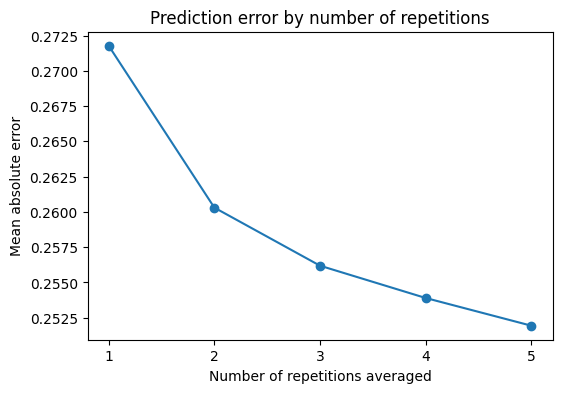

Interpretation: 
Across five possible single repetitions, mean MAE ws .272 and ranged from .254 to .283, indicating some sensitivity to seed. 
Averaging repetitions progressively reduced prediction error. 
The lowest MAE can be seen with the average of 5 repetitions, although most of the improvement occurs after the first few repetitions.


In [ ]:
import itertools
import matplotlib.pyplot as plt

repetitions = sorted(df["repetition"].dropna().unique())
rows = []

for k in range(1, len(repetitions) + 1):
    subset_maes = [] # a list for all the MAEs obtained from subsets of that size

    for subset in itertools.combinations(repetitions, k): # generates every possible subset
        subset_summary = (
            df[df["repetition"].isin(subset)] # keeps only the repetitions belonging to that particular subset
            .groupby(["question_id", "prompt_id"], as_index=False) # group the remaining responses by question x prompt
            .agg(
                prediction=("llm_scaled", "mean"), # averages the selected repetitions within each group
                actual_scaled=("actual_scaled", "first"),
            )
        )

        # calculates MAE for each particular subset
        mae = (
            subset_summary["prediction"]
            - subset_summary["actual_scaled"]
        ).abs().mean()

        subset_maes.append(mae)

    rows.append({
        "repetitions": k,
        "mean_MAE": np.mean(subset_maes),
        "best_subset_MAE": np.min(subset_maes),
        "worst_subset_MAE": np.max(subset_maes),
        "number_of_subsets": len(subset_maes),
    })

repetition_plateau = pd.DataFrame(rows)

display(repetition_plateau.round(3))

plt.figure(figsize=(6, 4))
plt.plot(
    repetition_plateau["repetitions"],
    repetition_plateau["mean_MAE"],
    marker="o",
)
plt.xticks(repetition_plateau["repetitions"])
plt.xlabel("Number of repetitions averaged")
plt.ylabel("Mean absolute error")
plt.title("Prediction error by number of repetitions")
plt.show()

print("Interpretation: \n"
      "Across five possible single repetitions, mean MAE ws .272 and ranged from .254 to .283, indicating some sensitivity to seed. \n"
      "Averaging repetitions progressively reduced prediction error. \n"
      "The lowest MAE can be seen with the average of 5 repetitions, although most of the improvement occurs after the first few repetitions.")

## 5. Prompt-template strategy

The previous section held the prompt fixed and examined variation across repeated generations. This section instead holds the question fixed and examines variation across the 10 different prompt templates.

We use data from repetition_summary table where all five repetitions are collapsed. Each row is therefore the "final" answer to one question x prompt.

This section asks:

1. How much do predictions vary across prompt templates?
2. How accurate is each individual prompt template?
3. How many prompt templates need to be combined before accuracy and prompt-choice sensitivity stabilize?

In [ ]:
# Takes all unique prompt IDs that appear. The IDs are [76, 77, 78, 79, 80, 81, 82, 83, 84, 85]
prompt_ids = sorted(repetition_summary["prompt_id"].unique().tolist())

# Retrieves those prompts from database
prompts_df = pd.DataFrame(
    database.client
    .table("prompts")
    .select("id, template_name")
    .in_("id", prompt_ids)
    .execute()
    .data
).rename(columns={"id": "prompt_id"})

# Each prompt prediction is the mean of 5 repetitions for each question x prompt combination
prompt_level = repetition_summary[
    ["question_id", "prompt_id", "mean_prediction", "actual_scaled", "norway_scaled",]
].merge(
    prompts_df,
    on="prompt_id",
    how="left",
    validate="many_to_one",
)
print(
    f"Prompt-level estimates: {len(prompt_level)} "
    f"({prompt_level['question_id'].nunique()} questions × "
    f"{prompt_level['prompt_id'].nunique()} prompts)"
)

Prompt-level estimates: 300 (30 questions × 10 prompts)


### 5.1 How much do predictions vary across prompt templates?

For each question, we calculate the SD across the 10 prompt-level predictions. The repeated generations have already been averaged within each prompt, so this variation reflects sensitivity to prompt formulation rather than seed variation.

As in Section 4, the predictions are on the normalized scale.

In [ ]:
# Groups the 10 prompt predictions belonging to the same question together
prompt_variation = (
    prompt_level
    .groupby("question_id", as_index=False)
    # Calculates the standard deviation across those 10 prompt predictions within each of the 30 questions
    .agg(
        prompt_sd=("mean_prediction", "std"),
        actual_scaled=("actual_scaled", "first"),
    )
)

# Summarizes 30 question-level SDs
prompt_variation_summary = pd.Series({
    "Mean prompt SD": prompt_variation["prompt_sd"].mean(),
    "Median prompt SD": prompt_variation["prompt_sd"].median(),
    "90th percentile SD": prompt_variation["prompt_sd"].quantile(0.90),
})

display(prompt_variation_summary.to_frame("value").round(3))

print("Interpretation: \n"
      "Across questions, the median SD across the 10 prompt formulations was 0.045. \n"
      "Thus, prompt formulations produced little variation and predictions remained relatively similar across prompt templates.")

,value
Mean prompt SD,0.056
Median prompt SD,0.045
90th percentile SD,0.101


Interpretation: 
Across questions, the median SD across the 10 prompt formulations was 0.045. 
Thus, prompt formulations produced little variation and predictions remained relatively similar across prompt templates.


### 5.2 How accurate is each individual prompt?

For each prompt template, MAE is calculated across the 30 questions using the prompt's mean prediction across 5 repetitions.

This is purely a descriptive comparison of prompt sensitivity, used to examine whether certain prompt templates show clear deviations. The best-performing prompt in the pilot will not automatically be selected for the main study.

In [ ]:
prompt_accuracy = (
    prompt_level
    .assign(
        absolute_error=lambda x: (
            x["mean_prediction"] - x["actual_scaled"] # |mean prompt prediction - actual outcome|
        ).abs()
    )
    .groupby(["prompt_id", "template_name"], as_index=False) # Groups together all 30 questions belonging to the same prompt template
    .agg(MAE=("absolute_error", "mean"))
    .sort_values("MAE")
)

display(prompt_accuracy.round(3))

print("Interpretation: \n"
      "The best and worst prompt differs by 0.050 in MAE, i.e., about 5% of the full normalized response scale. \n"
      "In other words, little prompt sensitivity and none of the prompt templates sticks out.")

,prompt_id,template_name,MAE
7,83,qwen_stepwise_reasoning_1,0.227
6,82,qwen_calibrated_forecast_1,0.242
5,81,qwen_adaptive_reasoning_1,0.248
9,85,qwen_verify_before_answer_1,0.249
4,80,qwen_grounded_outcome_1,0.249
1,77,baseline_structured_4,0.256
2,78,baseline_instructional_3,0.256
3,79,baseline_structured_3,0.257
8,84,qwen_plan_then_answer_1,0.259
0,76,baseline_instructional_4,0.277


Interpretation: 
The best and worst prompt differs by 0.050 in MAE, i.e., about 5% of the full normalized response scale. 
In other words, little prompt sensitivity and none of the prompt templates sticks out.


### 5.3 How many prompts are useful?

Another way to reduce sensitivity to prompt wording is to use a prompt ensemble, where predictions from several prompt templates are averaged. Here, we examine how prediction accuracy changes when averaging 1 to 10 prompt templates.

For each ensemble size, all possible combinations of prompts are evaluated. For example, when evaluating two-prompt ensembles, every possible pair of prompts is averaged into one prediction per question, MAE is calculated across the 30 questions, and the reported MAE is averaged across all possible prompt pairs.

The same procedure is repeated for ensembles of 1 through 10 prompts. This shows both how average prediction accuracy changes and how sensitive the result is to which prompt templates happen to be included.

,prompts,mean_MAE,best_subset_MAE,worst_subset_MAE,number_of_subsets
0,1,0.252,0.227,0.277,10
1,2,0.250,0.232,0.267,45
2,3,0.249,0.234,0.263,120
3,4,0.248,0.237,0.260,210
4,5,0.248,0.238,0.257,252
5,6,0.248,0.241,0.255,210
6,7,0.248,0.243,0.255,120
7,8,0.248,0.244,0.253,45
8,9,0.248,0.246,0.251,10
9,10,0.248,0.248,0.248,1


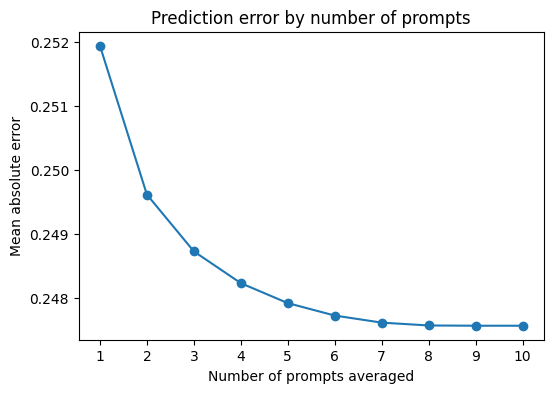

Interpretation: 
Averaging multiple prompt templates produced only a small improvement in average prediction accuracy. 
MAE decreased from 0.252 for a single prompt to approximately 0.248 for ensembles of four or more prompts. 
Prompt choice had a modest effect on MAE for single prompts, and this effect became progressively smaller 
as more prompt templates were averaged.


In [ ]:
prompt_ids = sorted(prompt_level["prompt_id"].unique())
rows = []

# Test ensembles containing 1, 2, ... up to all 10 prompts.
for k in range(1, len(prompt_ids) + 1):
    subset_maes = []

    # Generate every possible combination of k prompts.
    for subset in itertools.combinations(prompt_ids, k):

        # Average the selected prompt predictions into one prediction per question.
        subset_summary = (
            prompt_level[prompt_level["prompt_id"].isin(subset)]
            .groupby("question_id", as_index=False)
            .agg(
                prediction=("mean_prediction", "mean"),
                actual_scaled=("actual_scaled", "first"),
            )
        )

        # Calculate MAE across the 30 questions for this prompt combination.
        mae = (
            subset_summary["prediction"]
            - subset_summary["actual_scaled"]
        ).abs().mean()

        subset_maes.append(mae)

    # Summarize performance across all prompt combinations of size k.
    rows.append({
        "prompts": k,
        "mean_MAE": np.mean(subset_maes),
        "best_subset_MAE": np.min(subset_maes),
        "worst_subset_MAE": np.max(subset_maes),
        "number_of_subsets": len(subset_maes),
    })

prompt_plateau = pd.DataFrame(rows)

display(prompt_plateau.round(3))

# Plot average MAE by prompt-ensemble size.
plt.figure(figsize=(6, 4))
plt.plot(
    prompt_plateau["prompts"],
    prompt_plateau["mean_MAE"],
    marker="o",
)
plt.xticks(prompt_plateau["prompts"])
plt.xlabel("Number of prompts averaged")
plt.ylabel("Mean absolute error")
plt.title("Prediction error by number of prompts")
plt.show()

print(
    "Interpretation: \n"
    "Averaging multiple prompt templates produced only a small improvement in average prediction accuracy. \n"
    "MAE decreased from 0.252 for a single prompt to approximately 0.248 for ensembles of four or more prompts. \n"
    "Prompt choice had a modest effect on MAE for single prompts, and this effect became progressively smaller \n"
    "as more prompt templates were averaged."
)

## 6. Exploratory Qwen–human comparison

The previous sections evaluate methodological choices. We now examine LLM prediction per question and compare it with the Norwegian crowd prediction.

For this exploratory comparison:

1. the repeated generations are averaged within each prompt
2. the 10 prompt-level predictions are averaged
3. this produces one Qwen prediction for each of the 30 pilot questions.

We then ask three questions about prediction error:


1. **Error correlation:** Do Qwen and Norway tend to err on the same questions?
2. **Error size:** How large are Qwen's errors compared with Norway's?
3. **Error direction:** Do Qwen and Norway tend to overestimate or underestimate the same questions?


### 6.1 Construct one final Qwen prediction per question

The final Qwen estimate is the mean of the 10 prompt-level predictions, where each prompt-level prediction is itself the mean across repeated generations.

In [ ]:
# Groups together 10 prompt predictions belonging to each question
question_level = (
    prompt_level
    .groupby("question_id", as_index=False)
    .agg(
        qwen_prediction=("mean_prediction", "mean"), # Average 10 prompt-level prediction
        norway_prediction=("norway_scaled", "first"), # Norway only has one prediction per question (already aggregate)
        actual_scaled=("actual_scaled", "first"),
    )
)

# Absolute distance between qwen's final prediction and the real outcome for each question
question_level["qwen_absolute_error"] = (
    question_level["qwen_prediction"] - question_level["actual_scaled"]
).abs()

# Absolute distance between norway's answer and the real outcome for each question
question_level["norway_absolute_error"] = (
    question_level["norway_prediction"] - question_level["actual_scaled"]
).abs()

# Keeps direction of qwen's error
question_level["qwen_signed_error"] = (
    question_level["qwen_prediction"] - question_level["actual_scaled"]
)

# Keeps direction of Norway's error
question_level["norway_signed_error"] = (
    question_level["norway_prediction"] - question_level["actual_scaled"]
)

print(f"Final question-level predictions: {len(question_level)}")
display(question_level.head().round(3))

Final question-level predictions: 30


,question_id,qwen_prediction,norway_prediction,actual_scaled,qwen_absolute_error,norway_absolute_error,qwen_signed_error,norway_signed_error
0,S01E01_Q01,0.979,0.609,0.348,0.631,0.261,0.631,0.261
1,S01E01_Q04,0.145,0.400,0.747,0.602,0.347,-0.602,-0.347
2,S01E01_Q05,0.219,0.440,0.280,0.061,0.160,-0.061,0.160
3,S01E04_Q02,0.493,0.457,0.540,0.047,0.083,-0.047,-0.083
4,S02E01_Q08,0.352,0.360,0.054,0.298,0.306,0.298,0.306


### 6.2 Error correlation

First, we ask whether Qwen and the Norwegian crowd tend to find the same questions difficult.

We calculate the Spearman correlation between their **absolute errors** across the 30 questions.

- A positive correlation means that questions with larger Qwen errors also tend to have larger Norway errors.


Absolute-error Spearman rho: 0.640
Spearman p-value: 0.000
Absolute-error Pearson r: 0.674
Pearson p-value: 0.000


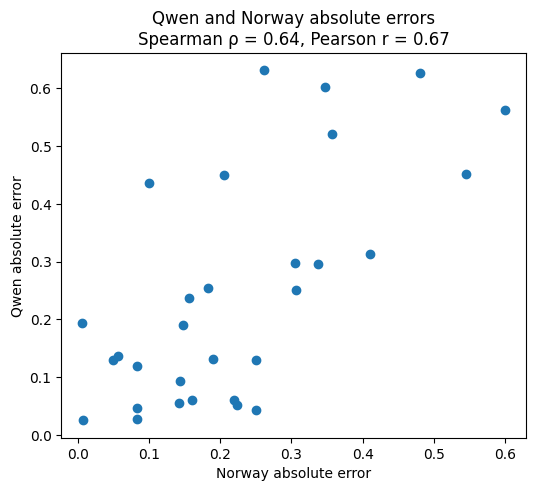

In [ ]:
from scipy.stats import spearmanr, pearsonr
import matplotlib.pyplot as plt

# Correlation between Qwen's and Norway's absolute errors.
absolute_error_spearman, spearman_p = spearmanr(
    question_level["qwen_absolute_error"],
    question_level["norway_absolute_error"],
)

absolute_error_pearson, pearson_p = pearsonr(
    question_level["qwen_absolute_error"],
    question_level["norway_absolute_error"],
)

print(f"Absolute-error Spearman rho: {absolute_error_spearman:.3f}")
print(f"Spearman p-value: {spearman_p:.3f}")
print(f"Absolute-error Pearson r: {absolute_error_pearson:.3f}")
print(f"Pearson p-value: {pearson_p:.3f}")

# Each point represents one question.
plt.figure(figsize=(6, 5))

plt.scatter(
    question_level["norway_absolute_error"],
    question_level["qwen_absolute_error"],
)

plt.xlabel("Norway absolute error")
plt.ylabel("Qwen absolute error")
plt.title(
    f"Qwen and Norway absolute errors\n"
    f"Spearman Ï = {absolute_error_spearman:.2f}, "
    f"Pearson r = {absolute_error_pearson:.2f}"
)

plt.show()

### 6.3 Error size

Next, we compare the size of Qwen's and Norway's prediction errors across the 30 questions.

**Mean absolute error (MAE)** is the average absolute distance between the prediction and the actual outcome:

$$
\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |\text{prediction}_i-\text{actual}_i|
$$

**Root mean squared error (RMSE)** also measures error size, but gives greater weight to larger errors:

$$
\text{RMSE} =
\sqrt{
\frac{1}{n}\sum_{i=1}^{n}
(\text{prediction}_i-\text{actual}_i)^2
}
$$


In [ ]:
qwen_rmse = np.sqrt(
    np.mean(
        (question_level["qwen_prediction"] - question_level["actual_scaled"]) ** 2
    )
)

norway_rmse = np.sqrt(
    np.mean(
        (question_level["norway_prediction"] - question_level["actual_scaled"]) ** 2
    )
)

error_size_results = pd.DataFrame({
    "source": ["Qwen", "Norway"],
    "MAE": [
        question_level["qwen_absolute_error"].mean(),
        question_level["norway_absolute_error"].mean(),
    ],
    "RMSE": [
        qwen_rmse,
        norway_rmse,
    ],
})

display(error_size_results.round(3))

,source,MAE,RMSE
0,Qwen,0.248,0.315
1,Norway,0.223,0.268


Because Qwen and Norway predict the same 30 questions, their MAEs can be compared **within the same set of questions**.

We calculate the observed difference in MAE as:

`Qwen MAE - Norway MAE`

A positive value means Qwen had the larger average absolute error. A negative value means Norway had the larger average absolute error.

We then bootstrap the 30 paired questions to obtain a 95% confidence interval around this MAE difference. The questions are resampled as paired observations, so Qwen's and Norway's errors for a given question always stay together.


In [ ]:
# Bootstrap the paired difference in MAE between Qwen and Norway.

rng = np.random.default_rng(1234)

qwen_errors = question_level["qwen_absolute_error"].to_numpy()
norway_errors = question_level["norway_absolute_error"].to_numpy()

n = len(question_level)

# Draw 10,000 bootstrap samples of the 30 paired questions.
bootstrap_indices = rng.integers(
    0,
    n,
    size=(10_000, n)
)

qwen_bootstrap_mae = qwen_errors[bootstrap_indices].mean(axis=1)
norway_bootstrap_mae = norway_errors[bootstrap_indices].mean(axis=1)

bootstrap_mae_difference = (
    qwen_bootstrap_mae - norway_bootstrap_mae
)

observed_difference = qwen_errors.mean() - norway_errors.mean()

ci_low, ci_high = np.quantile(
    bootstrap_mae_difference,
    [0.025, 0.975]
)

print(f"MAE difference (Qwen - Norway): {observed_difference:.3f}")
print(f"95% bootstrap CI: [{ci_low:.3f}, {ci_high:.3f}]")


MAE difference (Qwen - Norway): 0.024
95% bootstrap CI: [-0.025, 0.079]


#### Question-level heterogeneity

The overall MAEs can still hide question-level variation. Differences in opposite directions can cancel out when averaged.

Therefore, we also compare the two absolute errors for each question.


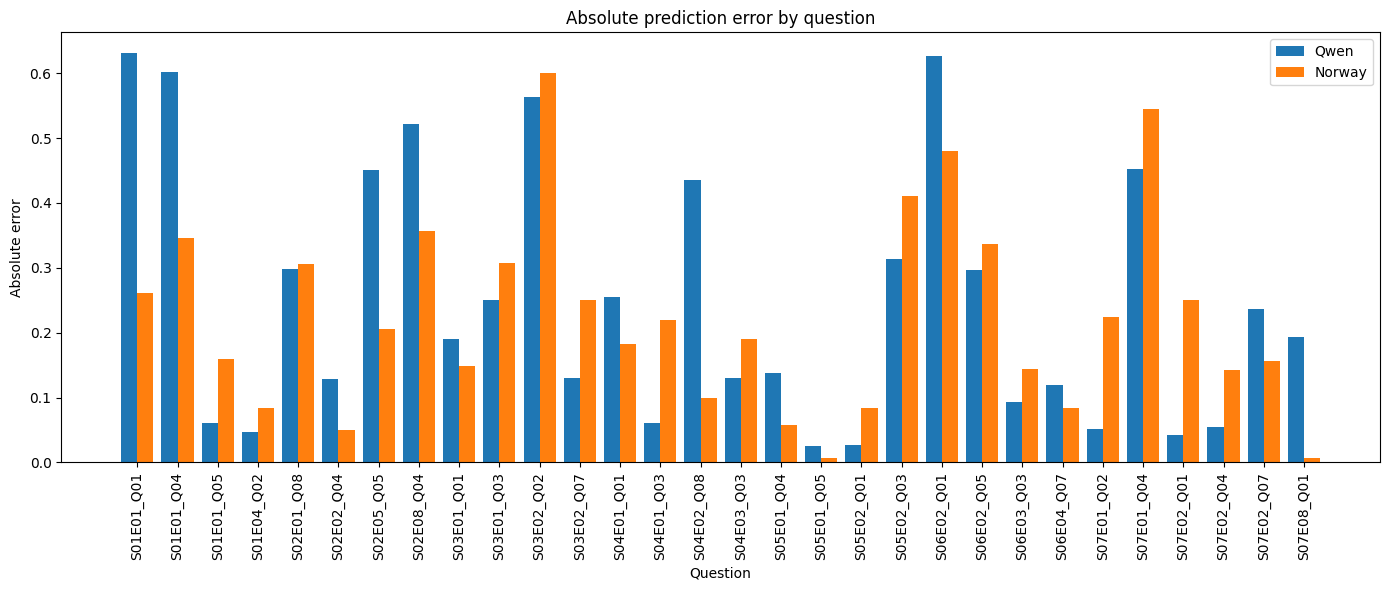

In [ ]:
# Question-by-question absolute errors

plot_data = question_level.copy()

x = np.arange(len(plot_data))
bar_width = 0.4

plt.figure(figsize=(14, 6))

plt.bar(
    x - bar_width / 2,
    plot_data["qwen_absolute_error"],
    width=bar_width,
    label="Qwen",
)

plt.bar(
    x + bar_width / 2,
    plot_data["norway_absolute_error"],
    width=bar_width,
    label="Norway",
)

plt.xticks(
    x,
    plot_data["question_id"],
    rotation=90,
)

plt.xlabel("Question")
plt.ylabel("Absolute error")
plt.title("Absolute prediction error by question")
plt.legend()

plt.tight_layout()
plt.show()


Mean paired absolute-error difference: 0.024
SD of paired absolute-error differences: 0.148


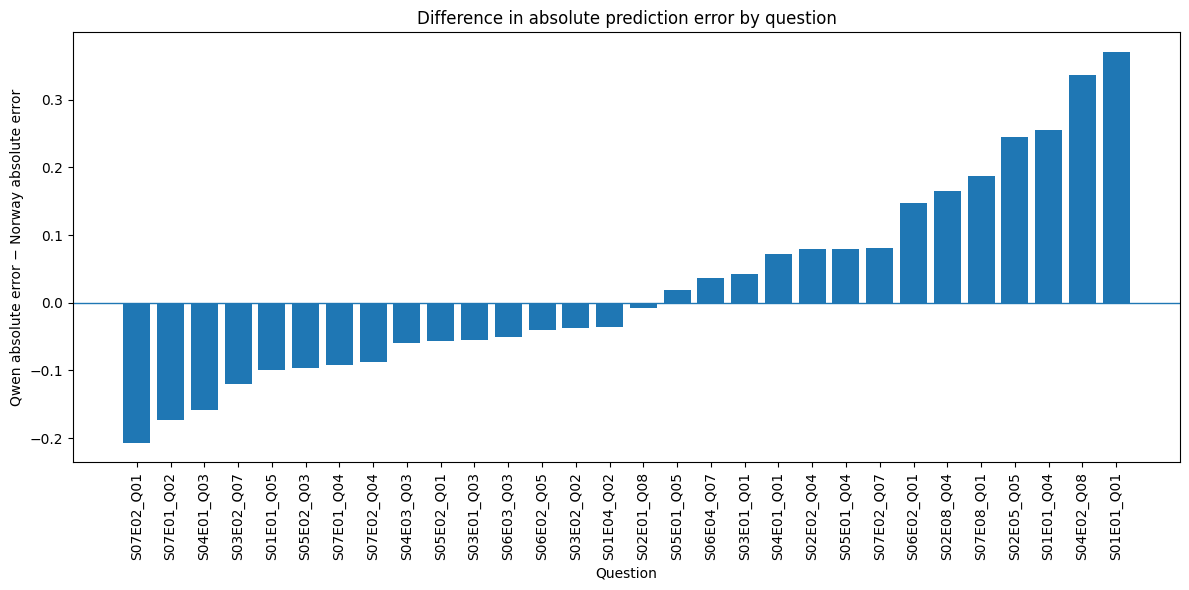

In [ ]:
# Difference in absolute error for each question. Positive = Qwen had larger error. Negative = Norway had larger error.
question_level["absolute_error_difference"] = (
    question_level["qwen_absolute_error"]
    - question_level["norway_absolute_error"]
)

# Takes the average of those 30 differences
mean_difference = question_level["absolute_error_difference"].mean()
# Calculates the standard deviation of those 30 Qwen - Norway differences
sd_difference = question_level["absolute_error_difference"].std()

print(f"Mean paired absolute-error difference: {mean_difference:.3f}")
print(f"SD of paired absolute-error differences: {sd_difference:.3f}")

plot_data = question_level.sort_values("absolute_error_difference")

plt.figure(figsize=(12, 6))

plt.bar(
    range(len(plot_data)),
    plot_data["absolute_error_difference"]
)

plt.axhline(0, linewidth=1)

plt.xticks(
    range(len(plot_data)),
    plot_data["question_id"],
    rotation=90
)

plt.xlabel("Question")
plt.ylabel("Qwen absolute error − Norway absolute error")
plt.title("Difference in absolute prediction error by question")

plt.tight_layout()
plt.show()

### 6.4 Error direction

Finally, we examine the direction of the prediction errors.

The **signed error** is:

$$
\text{prediction} - \text{actual}
$$

We use it in two ways:

1. **Mean signed error:** whether each predictor tends to overestimate or underestimate overall.
   - positive = average overestimation
   - negative = average underestimation
   - near zero = little average directional bias

2. **Signed-error correlation:** whether Qwen and Norway tend to overestimate and underestimate the same questions.
   - a positive correlation means their directional errors tend to move together across questions.

,source,mean_signed_error
0,Qwen,-0.047
1,Norway,-0.011


Signed-error Spearman rho: 0.741
p-value: 0.000
Same error direction: 25 of 30 questions (83.3%)


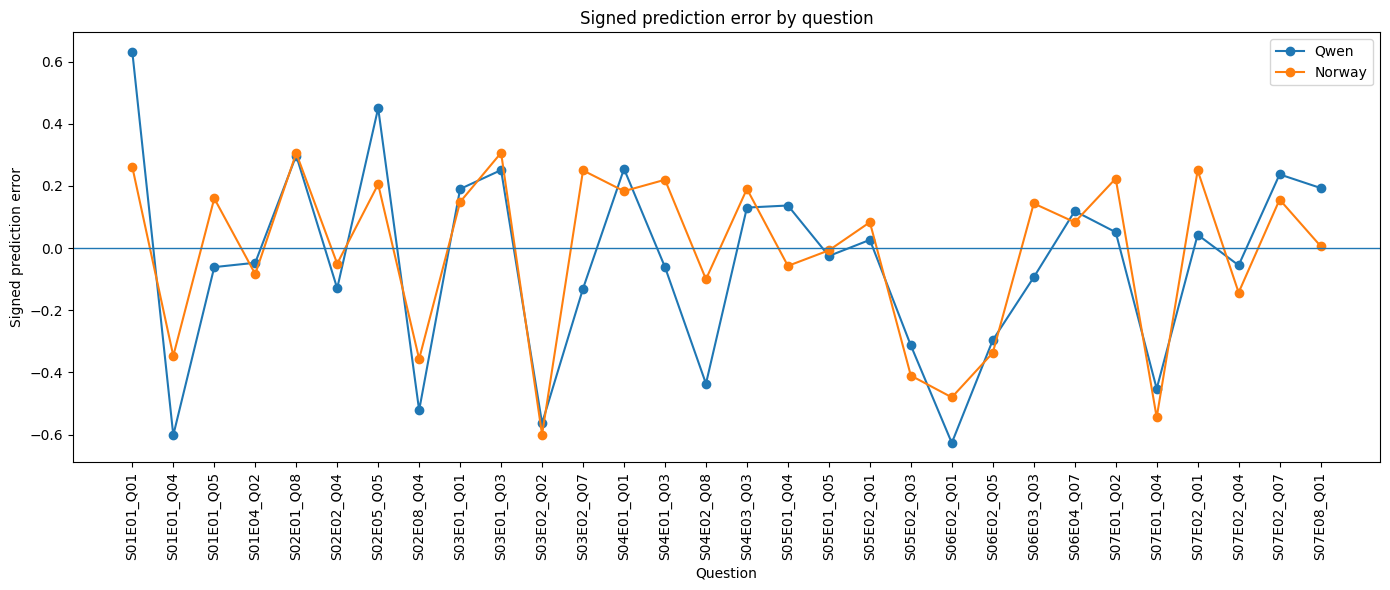

In [ ]:
error_direction_results = pd.DataFrame({
    "source": ["Qwen", "Norway"],
    "mean_signed_error": [
        question_level["qwen_signed_error"].mean(),
        question_level["norway_signed_error"].mean(),
    ],
})

signed_error_rho, signed_error_p = spearmanr(
    question_level["qwen_signed_error"],
    question_level["norway_signed_error"],
)

display(error_direction_results.round(3))
print(f"Signed-error Spearman rho: {signed_error_rho:.3f}")
print(f"p-value: {signed_error_p:.3f}")

same_direction = (
    np.sign(question_level["qwen_signed_error"])
    == np.sign(question_level["norway_signed_error"])
)

print(
    f"Same error direction: "
    f"{same_direction.sum()} of {len(question_level)} questions "
    f"({same_direction.mean():.1%})"
)

plot_data = question_level.copy()

x = np.arange(len(plot_data))

plt.figure(figsize=(14, 6))

plt.plot(
    x,
    plot_data["qwen_signed_error"],
    marker="o",
    label="Qwen"
)

plt.plot(
    x,
    plot_data["norway_signed_error"],
    marker="o",
    label="Norway"
)

plt.axhline(0, linewidth=1)

plt.xticks(
    x,
    plot_data["question_id"],
    rotation=90
)

plt.xlabel("Question")
plt.ylabel("Signed prediction error")
plt.title("Signed prediction error by question")

plt.legend()
plt.tight_layout()
plt.show()